In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import expm
from matplotlib.ticker import MultipleLocator

import sys  
sys.path.insert(1, 'python_files/')
import pulses
import qubits

In [2]:
E_C = 0.3*2*np.pi #Varausenergia (GHz)
E_J = 8*2*np.pi #Josephsonin energia (GHz)
qubit=qubits.Transmon(E_C,E_J,500)

f_ef = qubit.energies[2]-qubit.energies[1] #ef-siirtymän taajuus
f_gf = qubit.energies[2]-qubit.energies[0]

f_d=qubit.frequency
f_1=qubit.frequency*1.2
f_2=qubit.frequency*1.4

alpha=f_ef-qubit.frequency

#f_supp1=26.68287190734891
#f_supp2=32.677142425201396

f_supp1=f_1+alpha/2
f_supp2=f_2-alpha

c=1
d = 0.015
extra=0

In [3]:
print(f_gf,f_ef)
print(f_supp1,f_supp2)
print(f_1,f_2)

48.57030325890505 23.081701869396433
29.382871907354247 38.090941465424244
30.58632166741034 35.68404194531206


In [4]:
T_floquet = 2*np.pi/(f_d) #Floquet-jakson pituus
dt = T_floquet/20000 #Diskretoidaan aika-avaruus siten, että Floquet-jakson pituus on K aikapistettä
print(dt)
t_ramp=3

1.2325480733842487e-05


In [5]:
plt.rcParams["font.family"] = "serif"
plt.rcParams["font.serif"] = ["Times New Roman", "Times", "Nimbus Roman"]
plt.rcParams["mathtext.fontset"] = "stix"
plt.rcParams["font.size"] = 20

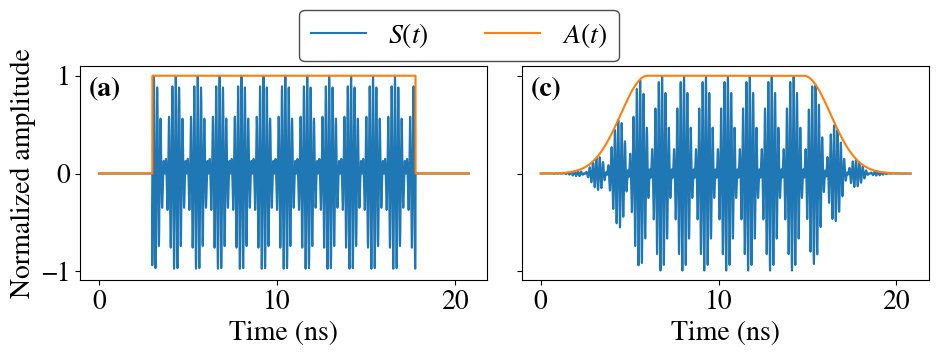

In [6]:
fig, axes = plt.subplots(1, 2, sharey=True, figsize=(10, 4))

N_edge = int(t_ramp/dt)
N_pulse = int((8.8 + 2*t_ramp) / dt)

testpulse_2f = pulses.Pulse(
    f_1*c, f_ef,
    [pulses.zero, pulses.one, pulses.zero],
    [N_edge, N_pulse, N_edge+extra],
    time_unit=dt,
    offset_input=f_d*t_ramp/(5*np.pi),
    second_frequency=f_2*c,
    drag=False
)

l1, = axes[0].plot(testpulse_2f.time_vals, testpulse_2f.raw/2)
l2, = axes[0].plot(testpulse_2f.time_vals, testpulse_2f.envelope)

axes[0].set_xlabel("Time (ns)")
axes[0].set_ylabel("Normalized amplitude")

# axes[0].legend(["$S(t)$", "$A(t)$"], loc="upper center", bbox_to_anchor=(0.5, 0.98), fontsize=16)

axes[0].text(0.02, 0.95, "(a)",
             transform=axes[0].transAxes,
             va="top",
             fontweight="bold")

N_edge = int(2*t_ramp/dt)
N_pulse = int(8.8 / dt)

testpulse_2f = pulses.Pulse(
    f_1*c, f_ef,
    [pulses.gaussian(2*t_ramp, t_ramp/2), pulses.one, pulses.gaussian_opp(0, t_ramp/2)],
    [N_edge, N_pulse, N_edge+extra],
    time_unit=dt,
    offset_input=0,
    second_frequency=f_2*c,
    drag=False
)

l3, = axes[1].plot(testpulse_2f.time_vals, testpulse_2f.raw/2)
l4, = axes[1].plot(testpulse_2f.time_vals, testpulse_2f.envelope)

axes[1].set_xlabel("Time (ns)")

# axes[1].legend(["$S(t)$", "$A(t)$"], loc="upper center", bbox_to_anchor=(0.5, 0.98), fontsize=16)

axes[1].text(0.02, 0.95, "(c)",
             transform=axes[1].transAxes,
             va="top",
             fontweight="bold")

fig.legend(
    [l1, l2],
    ["$S(t)$", "$A(t)$"],
    loc="upper center",
    bbox_to_anchor=(0.5, 0.95),
    ncol=2,
    frameon=True,
    facecolor="white",
    edgecolor="0.3",
    framealpha=1.0
)

plt.tight_layout(rect=[0, 0, 1, 0.85])
plt.savefig("kuvat/og-pulses-2f.pdf")
plt.show()

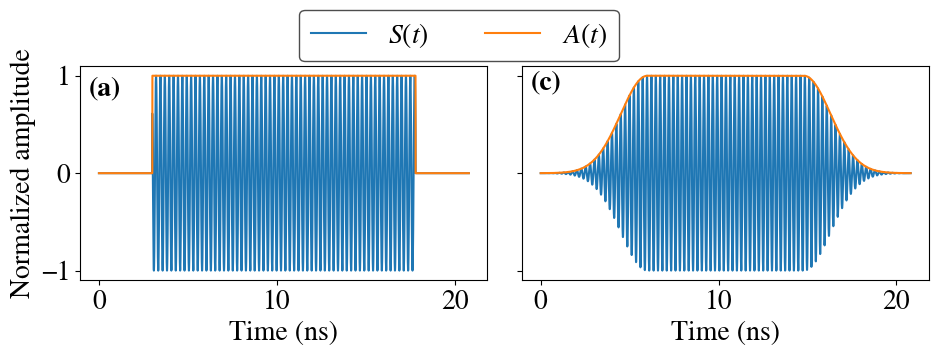

In [7]:
fig, axes = plt.subplots(1, 2, sharey=True, figsize=(10, 4))

N_edge = int(t_ramp/dt)
N_pulse = int((8.8 + 2*t_ramp) / dt)

testpulse = pulses.Pulse(
    f_d, f_ef,
    [pulses.zero, pulses.one, pulses.zero],
    [N_edge, N_pulse, N_edge+extra],
    time_unit=dt,
    offset_input=f_d*t_ramp/(5*np.pi),
    drag=False
)

axes[0].plot(testpulse.time_vals, testpulse.raw)
axes[0].plot(testpulse.time_vals, testpulse.envelope)
axes[0].set_xlabel("Time (ns)")
axes[0].set_ylabel("Normalized amplitude")
#axes[0].legend(["$S(t)$", "$A(t)$"], loc="upper center", bbox_to_anchor=(0.5, 0.98), fontsize=16)

axes[0].text(0.02, 0.95, "(a)",
             transform=axes[0].transAxes,
             va="top",
             fontweight="bold")

N_edge = int(2*t_ramp/dt)
N_pulse = int(8.8 / dt)

testpulse = pulses.Pulse(
    f_d, f_ef,
    [pulses.gaussian(2*t_ramp, t_ramp/2), pulses.one, pulses.gaussian_opp(0, t_ramp/2)],
    [N_edge, N_pulse, N_edge+extra],
    time_unit=dt,
    offset_input=0,
    drag=False
)

axes[1].plot(testpulse.time_vals, testpulse.raw)
axes[1].plot(testpulse.time_vals, testpulse.envelope)
axes[1].set_xlabel("Time (ns)")
#axes[1].legend(["$S(t)$", "$A(t)$"], loc="upper center", bbox_to_anchor=(0.5, 0.98), fontsize=16)

axes[1].text(0.02, 0.98, "(c)",
             transform=axes[1].transAxes,
             va="top",
             fontweight="bold")

fig.legend(
    [l1, l2],
    ["$S(t)$", "$A(t)$"],
    loc="upper center",
    bbox_to_anchor=(0.5, 0.95),
    ncol=2,
    frameon=True,
    facecolor="white",
    edgecolor="0.3",
    framealpha=1.0
)

plt.tight_layout(rect=[0, 0, 1, 0.85])
plt.savefig("kuvat/og-pulses.pdf")
plt.show()

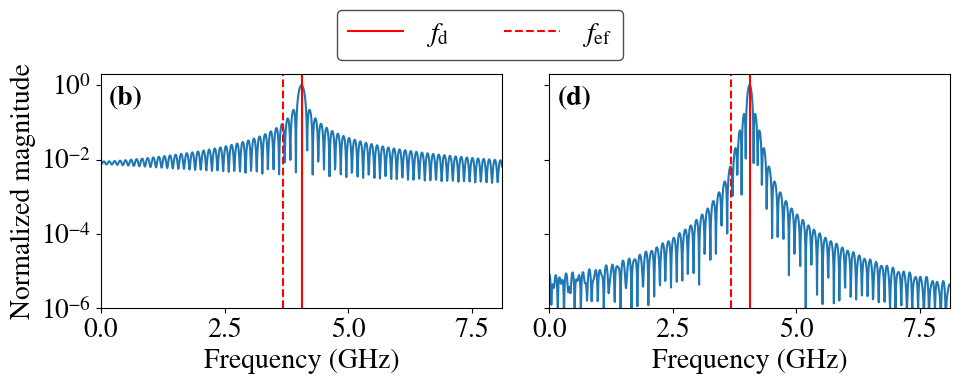

In [8]:
fig, axes = plt.subplots(1, 2, sharey=True, figsize=(10, 4))

N_edge = int(2*t_ramp/dt)
N_pulse = int(8.8/dt)
extra = 10000000

testpulse = pulses.Pulse(
    f_d, f_ef,
    [pulses.zero, pulses.one, pulses.zero],
    [N_edge, N_pulse, N_edge+extra],
    time_unit=dt,
    offset_input=f_d*t_ramp/(5*np.pi),
    drag=False
)

freqs = np.fft.rfftfreq(len(testpulse.time_vals), d=dt)
fourier = np.fft.rfft(testpulse.raw)

axes[0].semilogy(freqs, np.abs(fourier)/np.max(np.abs(fourier)))
l1 = axes[0].axvline(x=f_d/(2*np.pi), ymin=0, ymax=1, color='r', ls='-')
l2 = axes[0].axvline(x=f_ef/(2*np.pi), ymin=0, ymax=1, color='r', ls='--')
axes[0].set_xlim([0, 2*f_d/(2*np.pi)])
axes[0].set_ylim([1e-6, 2])
axes[0].set_xlabel("Frequency (GHz)")
axes[0].set_ylabel("Normalized magnitude")
axes[0].text(0.02, 0.95, "(b)",
             transform=axes[0].transAxes,
             va="top",
             fontweight="bold")

testpulse = pulses.Pulse(
    f_d, f_ef,
    [pulses.gaussian(2*t_ramp, t_ramp/2), pulses.one, pulses.gaussian_opp(0, t_ramp/2)],
    [N_edge, N_pulse, N_edge+extra],
    time_unit=dt,
    offset_input=0,
    drag=False
)

freqs = np.fft.rfftfreq(len(testpulse.time_vals), d=dt)
fourier = np.fft.rfft(testpulse.raw)

axes[1].semilogy(freqs, np.abs(fourier)/np.max(np.abs(fourier)))
l3 = axes[1].axvline(x=f_d/(2*np.pi), ymin=0, ymax=1, color='r', ls='-')
l4 = axes[1].axvline(x=f_ef/(2*np.pi), ymin=0, ymax=1, color='r', ls='--')
axes[1].set_xlim([0, 2*f_d/(2*np.pi)])
axes[1].set_ylim([1e-6, 2])
axes[1].set_xlabel("Frequency (GHz)")
axes[1].text(0.02, 0.95, "(d)",
             transform=axes[1].transAxes,
             va="top",
             fontweight="bold")

fig.legend(
    [l1, l2],
    ["$f_{\\mathrm{d}}$", "$f_{\\mathrm{ef}}$"],
    loc="upper center",
    bbox_to_anchor=(0.5, 1.02),
    ncol=2,
    frameon=True,
    facecolor="white",
    edgecolor="0.3",
    framealpha=1.0
)

plt.tight_layout(rect=[0, 0, 1, 0.9])
plt.savefig("kuvat/og-fourier.pdf")
plt.show()

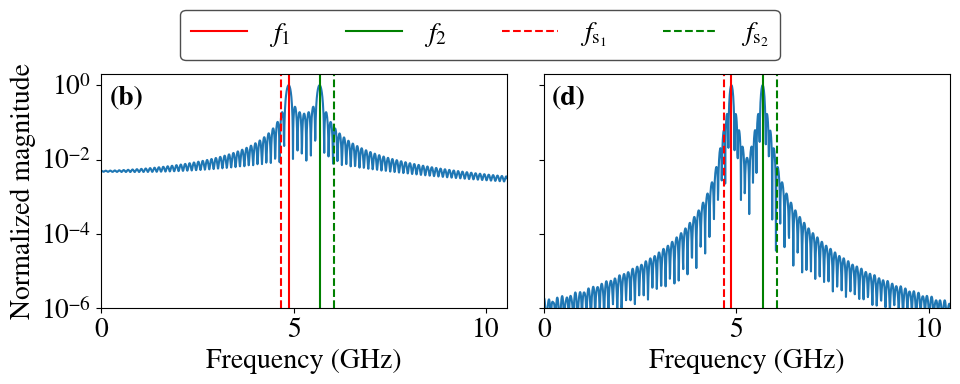

In [9]:
fig, axes = plt.subplots(1, 2, sharey=True, figsize=(10, 4))

N_edge = int(2*t_ramp/dt)
N_pulse = int(8.8/dt)
extra = 10000000

testpulse_2f = pulses.Pulse(
    f_1, f_ef,
    [pulses.zero, pulses.one, pulses.zero],
    [N_edge, N_pulse, N_edge+extra],
    time_unit=dt,
    offset_input=f_d*t_ramp/(5*np.pi),
    second_frequency=f_2,
    drag=False
)

freqs = np.fft.rfftfreq(len(testpulse_2f.time_vals), d=dt)
fourier1 = np.fft.rfft(testpulse_2f.raw)

axes[0].semilogy(freqs, np.abs(fourier1)/np.max(np.abs(fourier1)))
l1 = axes[0].axvline(x=f_1/(2*np.pi), ymin=0, ymax=1, color='r', ls='-')
l2 = axes[0].axvline(x=f_2/(2*np.pi), ymin=0, ymax=1, color='g', ls='-')
l3 = axes[0].axvline(x=f_supp1/(2*np.pi), ymin=0, ymax=1, color='r', ls='--')
l4 = axes[0].axvline(x=f_supp2/(2*np.pi), ymin=0, ymax=1, color='g', ls='--')
axes[0].set_xlim([0, (f_1+f_2)/(2*np.pi)])
axes[0].set_ylim([1e-6, 2])
axes[0].set_xlabel("Frequency (GHz)")
axes[0].set_ylabel("Normalized magnitude")
axes[0].text(0.02, 0.95, "(b)",
             transform=axes[0].transAxes,
             va="top",
             fontweight="bold")

testpulse_2f = pulses.Pulse(
    f_1*c, f_ef,
    [pulses.gaussian(2*t_ramp, t_ramp/2), pulses.one, pulses.gaussian_opp(0, t_ramp/2)],
    [N_edge, N_pulse, N_edge+extra],
    time_unit=dt,
    offset_input=0,
    second_frequency=f_2*c,
    drag=False
)

freqs = np.fft.rfftfreq(len(testpulse_2f.time_vals), d=dt)
fourier1 = np.fft.rfft(testpulse_2f.raw)

axes[1].semilogy(freqs, np.abs(fourier1)/np.max(np.abs(fourier1)))
l5 = axes[1].axvline(x=f_1/(2*np.pi), ymin=0, ymax=1, color='r', ls='-')
l6 = axes[1].axvline(x=f_2/(2*np.pi), ymin=0, ymax=1, color='g', ls='-')
l7 = axes[1].axvline(x=f_supp1/(2*np.pi), ymin=0, ymax=1, color='r', ls='--')
l8 = axes[1].axvline(x=f_supp2/(2*np.pi), ymin=0, ymax=1, color='g', ls='--')
axes[1].set_xlim([0, (f_1+f_2)/(2*np.pi)])
axes[1].set_ylim([1e-6, 2])
axes[1].set_xlabel("Frequency (GHz)")
axes[1].text(0.02, 0.95, "(d)",
             transform=axes[1].transAxes,
             va="top",
             fontweight="bold")

fig.legend(
    [l1, l2, l3, l4],
    ["$f_1$", "$f_2$", "$f_{\\mathrm{s}_1}$", "$f_{\\mathrm{s}_2}$"],
    loc="upper center",
    bbox_to_anchor=(0.5, 1.02),
    ncol=4,
    frameon=True,
    facecolor="white",
    edgecolor="0.3",
    framealpha=1.0
)

plt.tight_layout(rect=[0, 0, 1, 0.9])
plt.savefig("kuvat/og-fourier-2f.pdf")
plt.show()

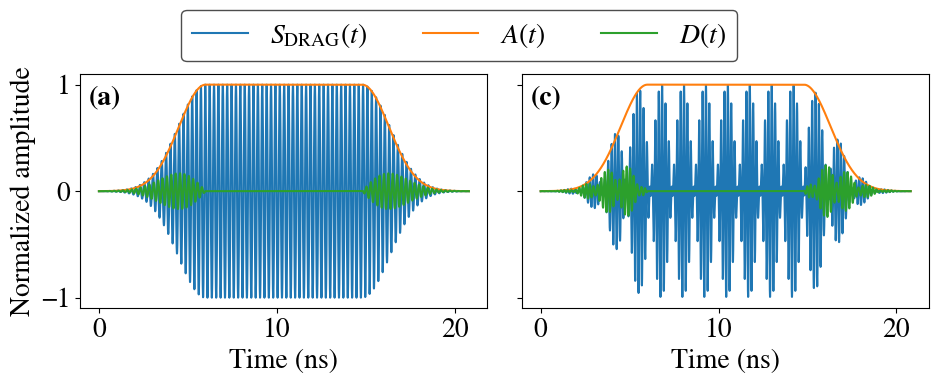

In [10]:
fig, axes = plt.subplots(1, 2, sharey=True, figsize=(10, 4))

N_edge = int(2*t_ramp/dt)
N_pulse = int(8.8/dt)
c = 1
extra = 0

testpulse = pulses.Pulse(
    f_d, f_ef,
    [pulses.gaussian(2*t_ramp, t_ramp/2), pulses.one, pulses.gaussian_opp(0, t_ramp/2)],
    [N_edge, N_pulse, N_edge+extra],
    time_unit=dt,
    offset_input=0,
    drag=True
)

l1, = axes[0].plot(testpulse.time_vals, testpulse.raw)
l2, = axes[0].plot(testpulse.time_vals, testpulse.envelope)
l3, = axes[0].plot(testpulse.time_vals, testpulse.drag_component)

axes[0].set_xlabel("Time (ns)")
axes[0].set_ylabel("Normalized amplitude")
axes[0].text(0.02, 0.95, "(a)",
             transform=axes[0].transAxes,
             va="top",
             fontweight="bold")

testpulse_2f = pulses.Pulse(
    f_1*c, [f_supp1, f_supp2],
    [pulses.gaussian(2*t_ramp, t_ramp/2), pulses.one, pulses.gaussian_opp(0, t_ramp/2)],
    [N_edge, N_pulse, N_edge+extra],
    time_unit=dt,
    offset_input=0,
    second_frequency=f_2*c,
    drag=True
)

axes[1].plot(testpulse_2f.time_vals, testpulse_2f.raw/2)
axes[1].plot(testpulse_2f.time_vals, testpulse_2f.envelope)
axes[1].plot(testpulse_2f.time_vals, testpulse_2f.drag_component/2)

axes[1].set_xlabel("Time (ns)")
axes[1].text(
    0.02, 0.95, "(c)",
    transform=axes[1].transAxes,
    va="top",
    fontweight="bold"
)

fig.legend(
    [l1, l2, l3],
    ["$S_\\mathrm{DRAG}(t)$", "$A(t)$", "$D(t)$"],
    loc="upper center",
    bbox_to_anchor=(0.5, 1.02),
    ncol=3,
    frameon=True,
    facecolor="white",
    edgecolor="0.3",
    framealpha=1.0
)

plt.tight_layout(rect=[0, 0, 1, 0.9])
plt.savefig("kuvat/drag-pulses.pdf")
plt.show()

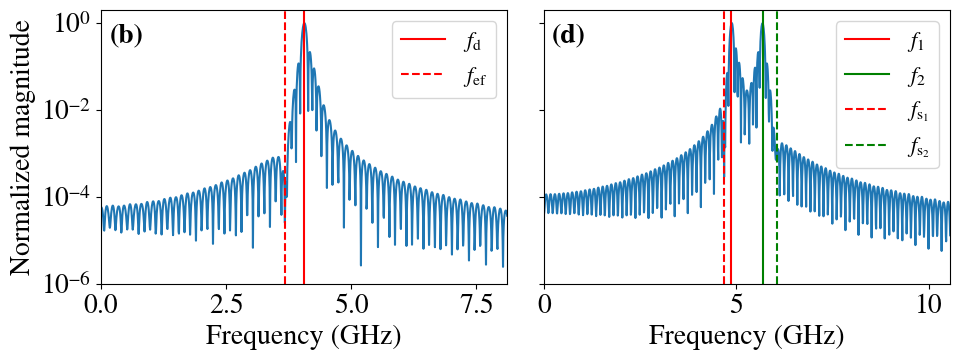

In [11]:
fig, axes = plt.subplots(1, 2, sharey=True, figsize=(10, 4))

N_edge = int(2*t_ramp/dt)
N_pulse = int(8.8/dt)
extra = 10000000

testpulse_2f = pulses.Pulse(
    f_d, f_ef,
    [pulses.gaussian(2*t_ramp, t_ramp/2), pulses.one, pulses.gaussian_opp(0, t_ramp/2)],
    [N_edge, N_pulse, N_edge+extra],
    time_unit=dt,
    offset_input=0,
    drag=True
)

freqs = np.fft.rfftfreq(len(testpulse_2f.time_vals), d=dt)
fourier1 = np.fft.rfft(testpulse_2f.raw)

axes[0].semilogy(freqs, np.abs(fourier1)/np.max(np.abs(fourier1)))
axes[0].axvline(x=f_d/(2*np.pi), ymin=0, ymax=1, color='r', ls='-',
                label="$f_{\\mathrm{d}}$")
axes[0].axvline(x=f_ef/(2*np.pi), ymin=0, ymax=1, color='r', ls='--',
                label="$f_{\\mathrm{ef}}$")
axes[0].set_xlim([0, 2*f_d/(2*np.pi)])
axes[0].set_ylim([1e-6, 2])
axes[0].set_xlabel("Frequency (GHz)")
axes[0].set_ylabel("Normalized magnitude")
axes[0].legend(loc="upper right", fontsize=16)
axes[0].text(0.02, 0.95, "(b)",
             transform=axes[0].transAxes,
             va="top",
             fontweight="bold")

testpulse_2f = pulses.Pulse(
    f_1, [f_supp1, f_supp2],
    [pulses.gaussian(2*t_ramp, t_ramp/2), pulses.one, pulses.gaussian_opp(0, t_ramp/2)],
    [N_edge, N_pulse, N_edge+extra],
    time_unit=dt,
    offset_input=0,
    second_frequency=f_2,
    drag=True
)

freqs = np.fft.rfftfreq(len(testpulse_2f.time_vals), d=dt)
fourier = np.fft.rfft(testpulse_2f.raw)

axes[1].semilogy(freqs, np.abs(fourier)/np.max(np.abs(fourier)))
axes[1].axvline(x=f_1/(2*np.pi), ymin=0, ymax=1, color='r', ls='-',
                label="$f_1$")
axes[1].axvline(x=f_2/(2*np.pi), ymin=0, ymax=1, color='g', ls='-',
                label="$f_2$")
axes[1].axvline(x=f_supp1/(2*np.pi), ymin=0, ymax=1, color='r', ls='--',
                label="$f_{\mathrm{s}_1}$")
axes[1].axvline(x=f_supp2/(2*np.pi), ymin=0, ymax=1, color='g', ls='--',
                label="$f_{\mathrm{s}_2}$")
axes[1].set_xlim([0, (f_1+f_2)/(2*np.pi)])
axes[1].set_ylim([1e-6, 2])
axes[1].set_xlabel("Frequency (GHz)")
axes[1].legend(loc="upper right", fontsize=16)
axes[1].text(0.02, 0.95, "(d)",
             transform=axes[1].transAxes,
             va="top",
             fontweight="bold")

plt.tight_layout()
plt.savefig("kuvat/drag-fourier-ex.pdf")
plt.show()

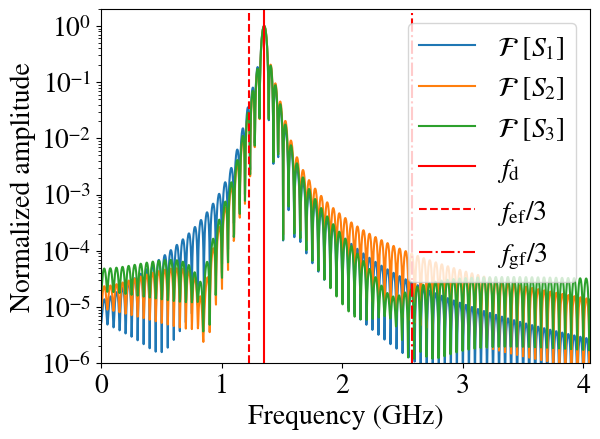

In [12]:
T_floquet = 6*np.pi/(f_d)
dt = T_floquet/20000 #Diskretoidaan aika-avaruus siten, että Floquet-jakson pituus on K aikapistettä
t_ramp=5

N_edge = int(3*t_ramp/dt)
N_pulse= int(20/(dt))

testpulse = pulses.Pulse(f_d/3,5.393900623136631,[pulses.gaussian(t_ramp*3,t_ramp/2),pulses.one,pulses.gaussian_opp(0,t_ramp/2)],[N_edge,N_pulse,N_edge+extra],time_unit=dt,offset_input=0,drag=False)
freqs = np.fft.rfftfreq(len(testpulse.time_vals), d=dt)
fourier_og = np.fft.rfft(testpulse.raw)

testpulse = pulses.Pulse(f_d/3,5.393900623136631,[pulses.gaussian(t_ramp*3,t_ramp/2),pulses.one,pulses.gaussian_opp(0,t_ramp/2)],[N_edge,N_pulse,N_edge+extra],time_unit=dt,offset_input=0,drag=True)
fourier = np.fft.rfft(testpulse.raw)

testpulse.second_drag(16.466338450511767)
fourier2 = np.fft.rfft(testpulse.raw)

plt.figure()

plt.semilogy(freqs, np.abs(fourier_og)/np.max(np.abs(fourier_og)))
plt.semilogy(freqs, np.abs(fourier)/np.max(np.abs(fourier)))
plt.semilogy(freqs, np.abs(fourier2)/np.max(np.abs(fourier2)))

plt.axvline(x=(f_d/3)/(2*np.pi), ymin=0, ymax=1, color='red',  ls='-')
plt.axvline(x=(f_ef/3)/(2*np.pi), ymin=0, ymax=1, color='red', ls='--')
#plt.axvline(x=f_gf/4, ymin=0, ymax=1, ls='-')
plt.axvline(x=(f_gf/3)/(2*np.pi), ymin=0, ymax=1, ls='-.', color='red')
#plt.axvline(x=f_gf/2, ymin=0, ymax=1, ls='-.')

plt.xlim([0,(3*f_d/3)/(2*np.pi)])
plt.ylim([10e-7,2])
plt.xlabel("Frequency (GHz)")
plt.ylabel("Normalized amplitude")
plt.legend(["$\mathcal{F}\ [S_1]$","$\mathcal{F}\ [S_2]$","$\mathcal{F}\ [S_3]$","$f_\mathrm{d}$","$f_{\mathrm{ef}}/3$","$f_{\mathrm{gf}}/3$"], loc="upper right")
#plt.title("DRAG-pulse")

plt.tight_layout()
plt.savefig("kuvat/drag-fourier.pdf")
plt.show()

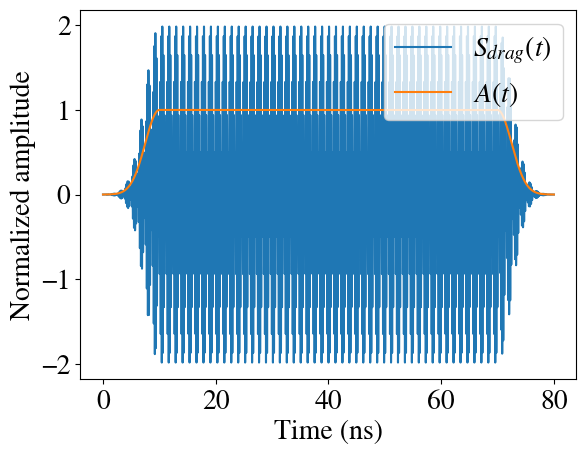

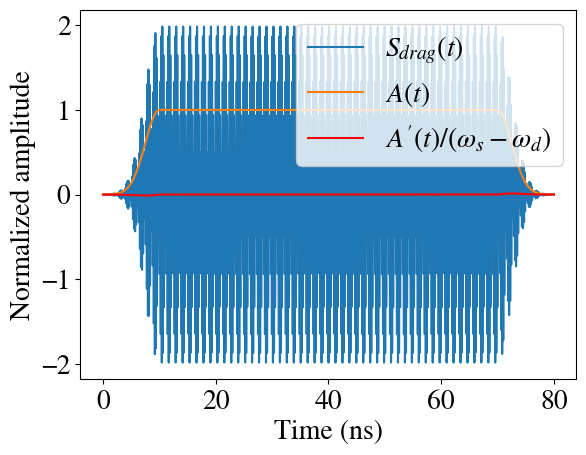

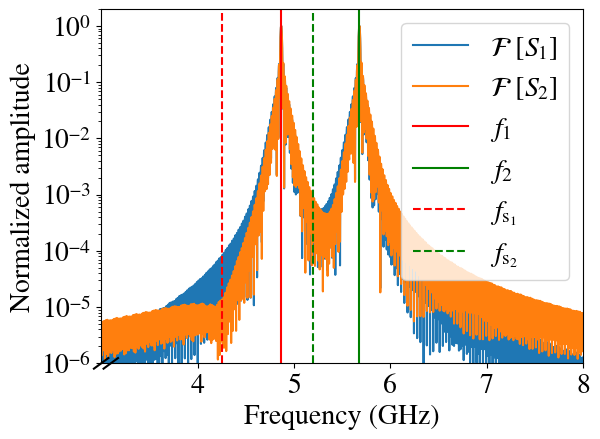

In [13]:
t_ramp=5
N_edge = int(2*t_ramp/dt)
N_pulse = int(60/dt)
extra = 10000000

testpulse = pulses.Pulse(
    f_1, [4.25*2*np.pi, 5.20*2*np.pi],
    [pulses.gaussian(2*t_ramp, t_ramp/2), pulses.one, pulses.gaussian_opp(0, t_ramp/2)],
    [N_edge, N_pulse, N_edge+extra],
    time_unit=dt,
    offset_input=0,
    second_frequency=f_2,
    drag=False
)

plt.figure()
plt.plot(testpulse.time_vals[:-extra],testpulse.raw[:-extra])
plt.plot(testpulse.time_vals[:-extra],testpulse.envelope[:-extra])

#plt.plot(testpulse.time_vals,testpulse.envelope_derivative/(f_ef/3-f_d+0.12))
#plt.xlim([10,30])
plt.xlabel("Time (ns)")
plt.ylabel("Normalized amplitude")
plt.legend(["$S_{drag}(t)$","$A(t)$","$A'(t)/(ω_s - ω_d)$"], loc="upper right")
plt.show()

freqs = np.fft.rfftfreq(len(testpulse.time_vals), d=dt)
fourier = np.fft.rfft(testpulse.raw)

testpulse = pulses.Pulse(
    f_1, [4.25*2*np.pi, 5.20*2*np.pi],
    [pulses.gaussian(2*t_ramp, t_ramp/2), pulses.one, pulses.gaussian_opp(0, t_ramp/2)],
    [N_edge, N_pulse, N_edge+extra],
    time_unit=dt,
    offset_input=0,
    second_frequency=f_2,
    drag=True
)

plt.figure()
plt.plot(testpulse.time_vals[:-extra],testpulse.raw[:-extra])
plt.plot(testpulse.time_vals[:-extra],testpulse.envelope[:-extra])
plt.plot(testpulse.time_vals[:-extra],testpulse.envelope_derivative[:-extra]/(5.393900623136631-f_d), color='r')

#plt.plot(testpulse.time_vals,testpulse.envelope_derivative/(f_ef/3-f_d+0.12))
#plt.xlim([10,30])
plt.xlabel("Time (ns)")
plt.ylabel("Normalized amplitude")
plt.legend(["$S_{drag}(t)$","$A(t)$","$A'(t)/(ω_s - ω_d)$"], loc="upper right")
plt.show()

fourier2 = np.fft.rfft(testpulse.raw)

plt.figure()

plt.semilogy(freqs, np.abs(fourier)/np.max(np.abs(fourier)))
plt.semilogy(freqs, np.abs(fourier2)/np.max(np.abs(fourier2)))

plt.axvline(x=f_1/(2*np.pi), ymin=0, ymax=1, color='red',  ls='-')
plt.axvline(x=f_2/(2*np.pi), ymin=0, ymax=1, color='g',  ls='-')
plt.axvline(x=4.25, ymin=0, ymax=1, color='red', ls='--')
plt.axvline(x=5.20, ymin=0, ymax=1, color='g', ls='--')
#plt.axvline(x=f_gf/4, ymin=0, ymax=1, ls='-')
#plt.axvline(x=f_ef/(2*np.pi), ymin=0, ymax=1, ls='-.', color='red')
#plt.axvline(x=f_gf/2, ymin=0, ymax=1, ls='-.')

plt.xlim([3, 8])
plt.ylim([10e-7,2])

ax = plt.gca()
d = 0.015
kwargs = dict(transform=ax.transAxes, color='k', clip_on=False, lw=1.5)

ax.plot((-d, +d), (-d, +d), **kwargs)
ax.plot((0.02 - d, 0.02 + d), (-d, +d), **kwargs)
ticks = ax.get_xticks()
ax.set_xticks([t for t in ticks if t != 3.0])

plt.xlabel("Frequency (GHz)")
plt.ylabel("Normalized amplitude")
plt.legend(["$\mathcal{F}\ [S_1]$","$\mathcal{F}\ [S_2]$","$f_\mathrm{1}$","$f_\mathrm{2}$","$f_{\mathrm{s}_1}$","$f_{\mathrm{s}_2}$"], loc="upper right")

plt.tight_layout()
plt.savefig("kuvat/drag-fourier-2f.pdf")
plt.show()

In [14]:
assert False

AssertionError: 

In [ ]:
extra=1000
t_ramp=5

testpulse = pulses.Pulse(f_d,f_ef/3,[pulses.gaussian(t_ramp*3,t_ramp/2),pulses.one,pulses.gaussian_opp(0,t_ramp/2)],[N_edge,N_pulse,N_edge+extra],time_unit=dt,offset_input=0,drag=False)

plt.figure()
plt.plot(testpulse.time_vals[:-extra],testpulse.raw[:-extra])
plt.plot(testpulse.time_vals[:-extra],testpulse.envelope[:-extra])
#plt.plot(testpulse.time_vals,testpulse.envelope_derivative/(f_ef/3-f_d+0.12))
#plt.xlim([10,30])
plt.xlabel("Time (ns)")
plt.ylabel("Normalized amplitude")
plt.legend(["$S(t)$","$A(t)$"], loc="upper right")
plt.show()

freqs = np.fft.rfftfreq(len(testpulse.time_vals), d=dt)
fourier = np.fft.rfft(testpulse.raw)

plt.figure()
plt.semilogy(freqs*2*np.pi, np.abs(fourier)/np.max(np.abs(fourier)))

plt.axvline(x=f_d, ymin=0, ymax=1, color='r', ls='--')
plt.axvline(x=f_ef/3, ymin=0, ymax=1, color='r', ls='-')
plt.axvline(x=f_gf/4, ymin=0, ymax=1, color='b', ls='-')
plt.axvline(x=f_gf/3, ymin=0, ymax=1, color='g', ls='-')
plt.axvline(x=f_gf/2, ymin=0, ymax=1, color='g', ls='--')


plt.xlim([f_d-3,f_d+20])
plt.ylim([0.000001,2])
plt.xlabel("Angular frequency (GHz)")
plt.ylabel("Normalized amplitude")
plt.legend(["$\mathcal{F}[S](ω)$","$ω_d$","$ω_{ef}/3$","$ω_{gf}/4$","$ω_{gf}/3$","$ω_{gf}/2$"], loc="upper right")
plt.title("Original pulse")
plt.show()

testpulse = pulses.Pulse(f_d,f_ef/3,[pulses.gaussian(t_ramp*3,t_ramp/2),pulses.one,pulses.gaussian_opp(0,t_ramp/2)],[N_edge,N_pulse,N_edge+extra],time_unit=dt,offset_input=0,drag=True)

plt.figure()
plt.plot(testpulse.time_vals[:-extra],testpulse.raw[:-extra])
plt.plot(testpulse.time_vals[:-extra],testpulse.envelope[:-extra])
plt.plot(testpulse.time_vals[:-extra],testpulse.envelope_derivative[:-extra]/(f_ef/3-f_d), color='r')

#plt.plot(testpulse.time_vals,testpulse.envelope_derivative/(f_ef/3-f_d+0.12))
#plt.xlim([10,30])
plt.xlabel("Time (ns)")
plt.ylabel("Normalized amplitude")
plt.legend(["$S_{drag}(t)$","$A(t)$","$A'(t)/(ω_s - ω_d)$"], loc="upper right")
plt.show()

freqs = np.fft.rfftfreq(len(testpulse.time_vals), d=dt)
fourier = np.fft.rfft(testpulse.raw)

plt.figure()
plt.semilogy(freqs*2*np.pi, np.abs(fourier)/np.max(np.abs(fourier)))

plt.axvline(x=f_d, ymin=0, ymax=1, color='r', ls='--')
plt.axvline(x=f_ef/3, ymin=0, ymax=1, color='r', ls='-')
plt.axvline(x=f_ef, ymin=0, ymax=1, color='r', ls='-')
plt.axvline(x=f_gf/4, ymin=0, ymax=1, color='b', ls='-')
plt.axvline(x=f_gf/3, ymin=0, ymax=1, color='g', ls='-')
plt.axvline(x=f_gf/2, ymin=0, ymax=1, color='g', ls='--')

plt.xlim([f_d-5,f_d+20])
plt.ylim([10e-10,2])
plt.xlabel("Angular frequency (10⁹ rad/s)")
plt.ylabel("Normalized amplitude")
plt.legend(["$\mathcal{F}[S](ω)$","$ω_d$","$ω_{ef}/3$","$ω_{ef}$","$ω_{gf}/4$","$ω_{gf}/3$","$ω_{gf}/2$"])
plt.title("DRAG-pulse")
plt.show()

testpulse.second_drag(16.466338450511767)
plt.figure()
plt.plot(testpulse.time_vals[:-extra],testpulse.raw[:-extra])
plt.plot(testpulse.time_vals[:-extra],testpulse.envelope[:-extra])
plt.plot(testpulse.time_vals[:-extra],testpulse.envelope_derivative[:-extra]/(f_ef/3-f_d), color='r')

#plt.plot(testpulse.time_vals,testpulse.envelope_derivative/(f_ef/3-f_d+0.12))
#plt.xlim([10,30])
plt.xlabel("Time (ns)")
plt.ylabel("Normalized amplitude")
plt.legend(["$S_{drag}(t)$","$A(t)$","$A'(t)/(ω_s - ω_d)$"], loc="upper right")
plt.show()

freqs = np.fft.rfftfreq(len(testpulse.time_vals), d=dt)
fourier = np.fft.rfft(testpulse.raw)

plt.figure()
plt.semilogy(freqs*2*np.pi, np.abs(fourier)/np.max(np.abs(fourier)))

plt.axvline(x=f_d, ymin=0, ymax=1, color='r', ls='--')
plt.axvline(x=f_ef/3, ymin=0, ymax=1, color='r', ls='-')
plt.axvline(x=f_ef, ymin=0, ymax=1, color='r', ls='-')
plt.axvline(x=f_gf/4, ymin=0, ymax=1, color='b', ls='-')
plt.axvline(x=f_gf/3, ymin=0, ymax=1, color='g', ls='-')
plt.axvline(x=f_gf/2, ymin=0, ymax=1, color='g', ls='--')

plt.xlim([f_d-5,f_d+20])
plt.ylim([10e-10,2])
plt.xlabel("Angular frequency (10⁹ rad/s)")
plt.ylabel("Normalized amplitude")
plt.legend(["$\mathcal{F}[S](ω)$","$ω_d$","$ω_{ef}/3$","$ω_{ef}$","$ω_{gf}/4$","$ω_{gf}/3$","$ω_{gf}/2$"], loc="upper right")
plt.title("DRAG-pulse")
plt.show()

In [ ]:
extra=1000000
#extra=0
testpulse = pulses.Pulse(f_d,f_ef/3,[pulses.gaussian(t_ramp*3,t_ramp/2),pulses.one,pulses.gaussian_opp(0,t_ramp/2)],[N_edge,N_pulse,N_edge+extra],time_unit=dt,offset_input=0,drag=False)

plt.figure()
plt.plot(testpulse.time_vals[:-extra],testpulse.raw[:-extra])
plt.plot(testpulse.time_vals[:-extra],testpulse.envelope[:-extra])
#plt.plot(testpulse.time_vals,testpulse.envelope_derivative/(f_ef/3-f_d+0.12))
#plt.xlim([10,30])
plt.xlabel("Time (ns)")
plt.ylabel("Normalized amplitude")
plt.legend(["$S(t)$","$A(t)$"], loc="upper right")
plt.show()

freqs = np.fft.rfftfreq(len(testpulse.time_vals), d=dt)
fourier = np.fft.rfft(testpulse.raw)

plt.figure()
plt.semilogy(freqs*2*np.pi, np.abs(fourier)/np.max(np.abs(fourier)))

plt.axvline(x=f_d, ymin=0, ymax=1, color='r', ls='--')
plt.axvline(x=f_ef/3, ymin=0, ymax=1, color='r', ls='-')
plt.axvline(x=f_gf/4, ymin=0, ymax=1, color='b', ls='-')
plt.axvline(x=f_gf/3, ymin=0, ymax=1, color='g', ls='-')
plt.axvline(x=f_gf/2, ymin=0, ymax=1, color='g', ls='--')


plt.xlim([f_d-3,f_d+20])
plt.ylim([0.000001,2])
plt.xlabel("Angular frequency (GHz)")
plt.ylabel("Normalized amplitude")
plt.legend(["$\mathcal{F}[S](ω)$","$ω_d$","$ω_{ef}/3$","$ω_{gf}/4$","$ω_{gf}/3$","$ω_{gf}/2$"])
plt.title("Original pulse")
plt.show()

testpulse = pulses.Pulse(f_d,f_ef/3,[pulses.gaussian(t_ramp*3,t_ramp/2),pulses.one,pulses.gaussian_opp(0,t_ramp/2)],[N_edge,N_pulse,N_edge+extra],time_unit=dt,offset_input=0,drag=True)

plt.figure()
plt.plot(testpulse.time_vals[:-extra],testpulse.raw[:-extra])
plt.plot(testpulse.time_vals[:-extra],testpulse.envelope[:-extra])
plt.plot(testpulse.time_vals[:-extra],testpulse.envelope_derivative[:-extra]/(f_ef/3-f_d), color='r')

#plt.plot(testpulse.time_vals,testpulse.envelope_derivative/(f_ef/3-f_d+0.12))
#plt.xlim([10,30])
plt.xlabel("Time (ns)")
plt.ylabel("Normalized amplitude")
plt.legend(["$S_{drag}(t)$","$A(t)$","$A'(t)/(ω_s - ω_d)$"], loc="upper right")
plt.show()

freqs = np.fft.rfftfreq(len(testpulse.time_vals), d=dt)
fourier = np.fft.rfft(testpulse.raw)

plt.figure()
plt.semilogy(freqs*2*np.pi, np.abs(fourier)/np.max(np.abs(fourier)))

plt.axvline(x=f_d, ymin=0, ymax=1, color='r', ls='--')
plt.axvline(x=f_ef/3, ymin=0, ymax=1, color='r', ls='-')
plt.axvline(x=f_gf/4, ymin=0, ymax=1, color='b', ls='-')
plt.axvline(x=f_gf/3, ymin=0, ymax=1, color='g', ls='-')
plt.axvline(x=f_gf/2, ymin=0, ymax=1, color='g', ls='--')

plt.xlim([f_d-3,f_d+20])
plt.ylim([0.000001,2])
plt.xlabel("Angular frequency (GHz)")
plt.ylabel("Normalized amplitude")
plt.legend(["$\mathcal{F}[S](ω)$","$ω_d$","$ω_{ef}/3$","$ω_{gf}/4$","$ω_{gf}/3$","$ω_{gf}/2$"])
plt.title("DRAG-pulse")
plt.show()

In [ ]:
def center_truncate(arr, target_len):
    if len(arr) <= target_len:
        return arr
    extra = len(arr) - target_len
    start = int(extra / 2)
    end = extra-start
    return arr[start:-end]

t_gap1=2*np.pi/(f_ef-f_1+f_2)
t_gap2=-np.pi/(f_ef-2*f_1)

N_edge1 = int((t_ramp*2+t_gap1/2)/dt)
N_edge2 = int((t_ramp*2-t_gap1/2)/dt)
N_gap1 = int((t_gap1)/dt)

N_edge3 = int((t_ramp*2+t_gap2/2)/dt)
N_edge4 = int((t_ramp*2-t_gap2/2)/dt)

N_edge = max(N_edge1,N_edge2,N_edge3,N_edge4)

N_gap2 = int((t_gap2)/dt)

#Kokonainen pulssi rampin aikakehityksen sekä Floquet-operaattorin laskemista varten
pulse1 = pulses.Pulse(f_1,f_ef,[pulses.gaussian(t_ramp*2-t_gap1/2,t_ramp/2),pulses.one,pulses.gaussian_opp(0,t_ramp/2)],[N_edge2,N_pulse,N_edge1],time_unit=dt,offset_input=0)
pulse2 = pulses.Pulse(f_1,f_ef,[pulses.gaussian(t_ramp*2+t_gap1/2,t_ramp/2),pulses.one,pulses.gaussian_opp(0,t_ramp/2)],[N_edge1,N_pulse,N_edge2],time_unit=dt,offset_input=t_gap1*f_1)

combined_pulse1 = (pulse1.raw + pulse2.raw)/2

pulse1 = pulses.Pulse(f_2,f_ef,[pulses.gaussian(t_ramp*2-t_gap2/2,t_ramp/2),pulses.one,pulses.gaussian_opp(0,t_ramp/2)],[N_edge4,N_pulse,N_edge3],time_unit=dt,offset_input=0)
pulse2 = pulses.Pulse(f_2,f_ef,[pulses.gaussian(t_ramp*2+t_gap2/2,t_ramp/2),pulses.one,pulses.gaussian_opp(0,t_ramp/2)],[N_edge3,N_pulse,N_edge4],time_unit=dt,offset_input=t_gap1*f_2)

combined_pulse2 = (pulse1.raw + pulse2.raw)/2

pulse_length=min(len(combined_pulse1),len(combined_pulse2))

combined_pulse = center_truncate(combined_pulse1,pulse_length)-center_truncate(combined_pulse2,pulse_length)

print(N_edge1,N_edge2,N_edge3,N_edge4)

plt.figure()
plt.plot(pulse1.time_vals,combined_pulse)
#plt.xlim([0,20])
plt.xlabel("Aika (ms)")
plt.ylabel("Normalisoitu amplitudi")
plt.title("Pulssi1")
plt.show()

In [ ]:
f_supp=f_ef/3

extra=100000000

t_gap=np.pi/(f_supp)
#t_gap=0
t_ramp_new=t_ramp-t_gap/2

phi=t_gap*f_d

N_edge1 = int((t_ramp_new*3+t_gap/2)/dt)
N_edge2 = int((t_ramp_new*3-t_gap/2)/dt)

#Kokonainen pulssi rampin aikakehityksen sekä Floquet-operaattorin laskemista varten
pulse1 = pulses.Pulse(f_d,f_supp,[pulses.gaussian(t_ramp_new*3-t_gap/2,t_ramp_new/2),pulses.one,pulses.gaussian_opp(0,t_ramp_new/2)],[N_edge2,N_pulse,N_edge1+extra],time_unit=dt,offset_input=-phi/2)
pulse2 = pulses.Pulse(f_d,f_supp,[pulses.gaussian(t_ramp_new*3+t_gap/2,t_ramp_new/2),pulses.one,pulses.gaussian_opp(0,t_ramp_new/2)],[N_edge1,N_pulse,N_edge2+extra],time_unit=dt,offset_input=phi/2)

combined_pulse = pulse1.raw + pulse2.raw
m = 2*np.abs(np.cos(phi/2))


plt.figure()
plt.plot(pulse1.time_vals[:-extra],pulse1.raw[:-extra])
plt.plot(pulse1.time_vals[:-extra],pulse2.raw[:-extra])
plt.xlabel("Time (ns)")
plt.ylabel("Normalized amplitude")
plt.legend(["$S(t)$","$S(t-t_{gap})$"], loc="upper right")
plt.show

plt.figure()
plt.plot(pulse1.time_vals[:-extra],combined_pulse[:-extra]/m)
plt.xlabel("Time (ns)")
plt.ylabel("Normalized amplitude")
plt.legend(["$\mathcal{N}(S(t)+S(t-t_{gap}))$"], loc="upper right")
plt.show()

freqs = np.fft.rfftfreq(len(pulse1.time_vals), d=dt)
fourier = np.fft.rfft(combined_pulse/m)

plt.figure()
plt.semilogy(freqs*2*np.pi, np.abs(fourier)/np.max(np.abs(fourier)))

plt.axvline(x=f_d, ymin=0, ymax=1, color='r', ls='--')
plt.axvline(x=f_ef/3, ymin=0, ymax=1, color='r', ls='-')

plt.xlim([f_d-3,f_d+3])
plt.ylim([0.000001,2])
plt.xlabel("Angular frequency (GHz)")
plt.ylabel("Normalized amplitude")
plt.legend(["$\mathcal{F}[S_{two}](ω)$","$ω_d$","$ω_{s}$"])
plt.show()